In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
matplotlib.rcParams['figure.figsize'] = (8, 8)
sns.set_style('whitegrid')

Имеем: $\ f(x) \to \min\limits_{x}$, $\quad x \in \mathbb{R}^n, \quad f : \mathbb{R}^n \to \mathbb{R}  $

${\bf \text{Необходимое условие экстремума:}}$

$\quad$ Если $x^{\ast}$ - точка локального экстремума (минимума/максимума) $\quad \Rightarrow \quad \nabla f(x^{\ast}) = 0$

${\bf \text{Достаточное условие экстремума:}}$

$\quad$ Если $x^{\ast}$ - точка локального минимума (максимума) $\quad \Rightarrow \quad \nabla^2 f(x^{\ast}) > 0 \quad (< 0), \qquad \left(\nabla^2 f(x) - \text{матрица Гессиан}\right)$

$f(x) = -2 \cdot \log(x) - 3 \cdot x - \log(1 - x^2) \to \min\limits_{x}$

Идея метода заключается в следующем: градиент $\nabla f(x)$ - это вектор, который показывает направление наискорейшего роста функции. Тогда направление, задаваемое вектором $- \nabla f(x)$ будет вести к наискорейшему убыванию значения функции $f(x)$.  

${\bf GD:}$

$x_{new} = x_{old} - \nabla f(x_{old})$

In [3]:
def f(x):
    if isinstance(x, int) or isinstance(x, float):
        x = [x]
    return np.array([-2*np.log(x_) - 3*x_ - np.log(1 - x_**2) for x_ in x])

def d1_f(x):
    if isinstance(x, int) or isinstance(x, float):
        x = [x]
    return np.array([-2/x_ -3 + (2*x_)/(1 - x_**2) for x_ in x])

def d2_f(x):
    if isinstance(x, int) or isinstance(x, float):
        x = [x]
    return np.array([2/x_**2 + (2 + 2*x_**2)/(1 - x_**2)**2 for x_ in x])

In [4]:
alpha = 0.03
x_old = 0.2
x_new = x_old
history_x_list = [x_old]
history_y_list = [f(x_old)[0]]
history_steps_list = []
for i in range(5):
    print(f'step {i+1}:')
    x_new = x_old - alpha*d1_f(x_old)[0]
    history_steps_list.append(-alpha*d1_f(x_old)[0])
    x_old = x_new
    print(f'x: {x_new:.4f}', end='\n'*2)
    history_x_list.append(x_old)
    history_y_list.append(f(x_old)[0])
history_steps_list.append(0)

step 1:
x: 0.5775

step 2:
x: 0.7194

step 3:
x: 0.8033

step 4:
x: 0.8321

step 5:
x: 0.8319



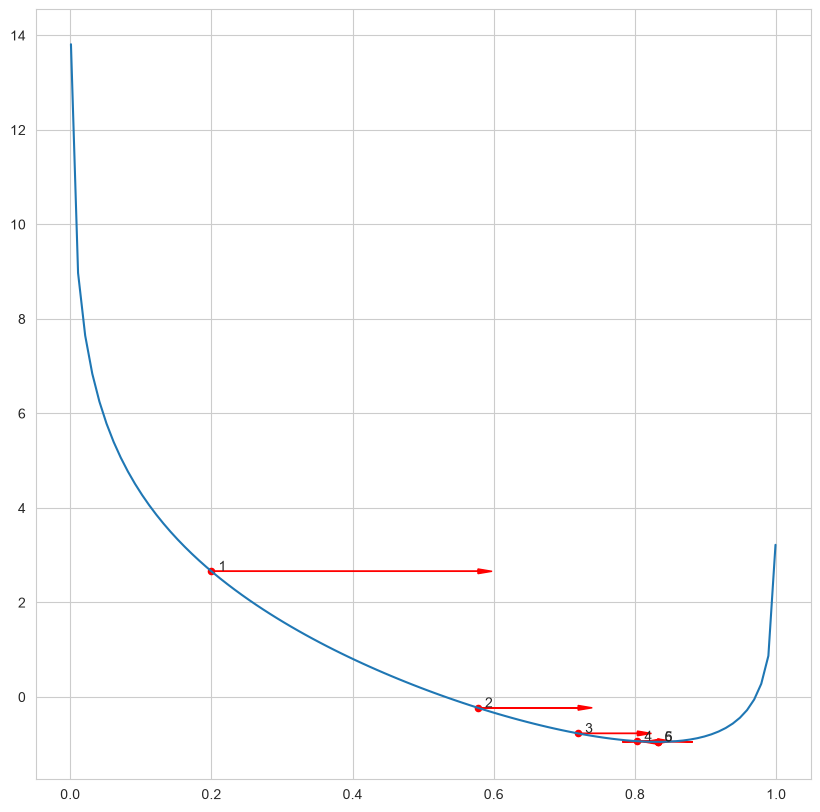

In [5]:
# Функция определена только при 0 < x < 1
x_dom = np.linspace(1e-3, 1 - 1e-3, 100)

plt.figure(figsize=(10, 10))
plt.plot(x_dom, f(x_dom))
for i in range(len(history_x_list)):
    plt.scatter(history_x_list[i], history_y_list[i], color='red', s=20)
    plt.text(history_x_list[i] + 0.01, history_y_list[i] + 0.01, i + 1, size=10)
    plt.arrow(history_x_list[i], history_y_list[i], history_steps_list[i], 0, head_width=0.1, head_length=0.02, color='red') # отрисовка антиградиентов